In [1]:
import os
import glob
import numpy as np
import pandas as pd
import pickle
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

from scipy.ndimage import gaussian_filter1d

from scipy import stats
import statsmodels.formula.api as smf

sns.set_context('poster')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# import Python3_OpenOE_AC_map_functions_v1_08_30s as oem
import mz_LFP_functions as mz_LFP

#for the animation plot video at the very bottom!
import matplotlib.animation as ani

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth": 2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size": 8, "ytick.major.size": 8})
    # optional, makes markers bigger, too, axes.linewidth doesn't seem to work
    plt.rcParams['axes.linewidth'] = 2.5

rc_pub={'font.size': 25, 'axes.labelsize': 25, 'legend.fontsize': 25.0, 
    'axes.titlesize': 25, 'xtick.labelsize': 25, 'ytick.labelsize': 25, 
    #'axes.color_cycle':pal, # image.cmap - rewritesd the default colormap
    'axes.linewidth':2.5, 'lines.linewidth': 2.5,
    'xtick.color': 'black', 'ytick.color': 'black', 'axes.edgecolor': 'black','axes.labelcolor':'black','text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

#set_pub_bargraphs()
set_pub_plots()

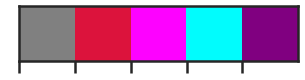

In [3]:
pal=sns.blend_palette(['gray','crimson','magenta','cyan','purple'],5)
sns.palplot(pal)
sns.set_palette(pal)

# Load some necessary variables

In [4]:
insert_depth = 3100  #change this as appropriate

sp_bw_ch = 20/2

surface_ch = np.round(insert_depth/sp_bw_ch)
V1_hip_ch = np.round((insert_depth-1000)/sp_bw_ch)
Hip_thal_ch = np.round((insert_depth-1000-1200)/sp_bw_ch)

CA1_DG_ch = np.round((insert_depth-1000-600)/sp_bw_ch)

print(surface_ch, V1_hip_ch, Hip_thal_ch, CA1_DG_ch)

310.0 210.0 90.0 150.0


In [5]:
samples_tr = 7350 #this is based on the shortest #samples in a trial
sr = 2500
n_chan = 384
rec_length = 3.0 #how long is the arduino triggered?

---

---

---

# First, load in the .npy arrays and CC_ls
These were creaded and saved using the "1_saving_LFP_arrays" jupyter notebook

In [6]:
all1_rew_arr = np.load(r"D:\mz_Data\saved_dfs\Operant_reward\lfp_npy\1sec_all_rew.npy")
all1_rew2_arr = np.load(r"D:\mz_Data\saved_dfs\Operant_reward\lfp_npy\1sec_all_rew2.npy")
all1_unrew_arr = np.load(r"D:\mz_Data\saved_dfs\Operant_reward\lfp_npy\1sec_all_unrew.npy")

all2_rew_arr = np.load(r"D:\mz_Data\saved_dfs\Operant_reward\lfp_npy\2sec_all_rew.npy")
all2_rew2_arr = np.load(r"D:\mz_Data\saved_dfs\Operant_reward\lfp_npy\2sec_all_rew2.npy")
all2_unrew_arr = np.load(r"D:\mz_Data\saved_dfs\Operant_reward\lfp_npy\2sec_all_unrew.npy")

In [7]:
pkl1_file = r"D:\mz_Data\saved_dfs\Operant_reward\lfp_npy\1sec_cc_ls"
pkl2_file = r"D:\mz_Data\saved_dfs\Operant_reward\lfp_npy\2sec_cc_ls"

open_file = open(pkl1_file, "rb")
CC_ls1 = pickle.load(open_file)
open_file.close()

open_file = open(pkl2_file, "rb")
CC_ls2 = pickle.load(open_file)
open_file.close()

In [12]:
def VEP_lines(data_array, CC_ls):
    groupA = []
    groupB = []
    for i in range(data_array.shape[0]):
        if (CC_ls[i] == "CC082263") | (CC_ls[i] == "CC067489") | (CC_ls[i] == "CC082260") | (CC_ls[i] == "CC084621"):
            groupA.append(data_array[i])
        elif (CC_ls[i] == "CC082257") | (CC_ls[i] == "CC067431") | (CC_ls[i] == "CC067432") | (CC_ls[i] == "CC082255"):
            groupB.append(data_array[i])

    groupA_arr = np.array(groupA)
    groupB_arr = np.array(groupB)

    mean_A = groupA_arr.mean(axis=0)
    mean_B = groupB_arr.mean(axis=0)

#     print('Group A array: {0}'.format(groupA_arr.shape))
#     print('Group A mean: {0}'.format(mean_A.shape))

#     print('Group B array: {0}'.format(groupB_arr.shape))
#     print('Group B mean: {0}'.format(mean_B.shape))

    V1_A = mean_A[200:300, :]
    min_A = np.where(V1_A == np.amin(V1_A))
    min_ch_A = min_A[0][0] + 199
#     print(min_ch_A)

    V1_B = mean_B[200:300, :]
    min_B = np.where(V1_B == np.amin(V1_B))
    min_ch_B = min_B[0][0] + 199
#     print(min_ch_B)
    
    return mean_A, mean_B, min_ch_A, min_ch_B

In [13]:
# 1-second interval reward recordings
# Rewarded with water
r1_meanA1, r1_meanB1, r1_minch_A1, r1_minch_B1 = VEP_lines(all1_rew_arr, CC_ls1)

# Rewarded without water
r2_meanA1, r2_meanB1, r2_minch_A1, r2_minch_B1 = VEP_lines(all1_rew2_arr, CC_ls1)

# Unrewarded
nr_meanA1, nr_meanB1, nr_minch_A1, nr_minch_B1 = VEP_lines(all1_unrew_arr, CC_ls1)

In [14]:
# 2-second interval reward recordings
# Rewarded with water
r1_meanA2, r1_meanB2, r1_minch_A2, r1_minch_B2 = VEP_lines(all2_rew_arr, CC_ls2)

# Rewarded without water
r2_meanA2, r2_meanB2, r2_minch_A2, r2_minch_B2 = VEP_lines(all2_rew2_arr, CC_ls2)

# Unrewarded
nr_meanA2, nr_meanB2, nr_minch_A2, nr_minch_B2 = VEP_lines(all2_unrew_arr, CC_ls2)

# Plot the various situations

In [29]:
# plt.rcdefaults()

In [33]:
wt_rew_1sec = r1_meanA1[r1_minch_A1,:]
wt_rew_2sec = r1_meanA2[r1_minch_A2,:]
wt_rew2_1sec = r2_meanA1[r2_minch_A1,:]
wt_rew2_2sec = r2_meanA2[r2_minch_A2,:]
wt_unrew_1sec = nr_meanA1[nr_minch_A1,:]
wt_unrew_2sec = nr_meanA2[nr_minch_A2,:]

time_array = np.linspace(0, wt_rew_1sec.shape[0]/sr, wt_rew_1sec.shape[0])

fx_rew_1sec = r1_meanB1[r1_minch_B1,:]
fx_rew_2sec = r1_meanB2[r1_minch_B2,:]
fx_rew2_1sec = r2_meanB1[r2_minch_B1,:]
fx_rew2_2sec = r2_meanB2[r2_minch_B2,:]
fx_unrew_1sec = nr_meanB1[nr_minch_B1,:]
fx_unrew_2sec = nr_meanB2[nr_minch_B2,:]

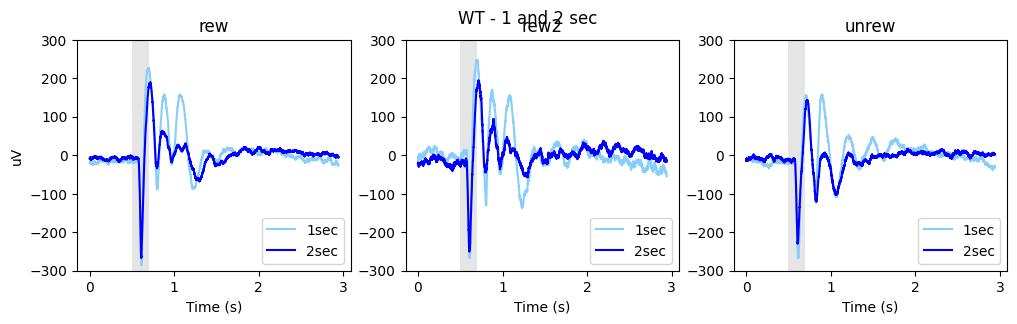

In [37]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 12.0 # x dimension
fig_size[1] = 3.0 # y dimension

plt.suptitle('WT - 1 and 2 sec')

ax1 = plt.subplot(131)
plt.plot(time_array, wt_rew_1sec, label='1sec', color='lightskyblue')
plt.plot(time_array, wt_rew_2sec, label='2sec', color='blue')
plt.legend(loc="lower right")
plt.title('rew')
plt.xlabel('Time (s)')
plt.ylabel('uV')
plt.ylim([-300,300])
plt.axvspan(0.5, 0.7, alpha=0.2, facecolor='grey')

ax1 = plt.subplot(132, sharex=ax1, sharey=ax1)
plt.plot(time_array, wt_rew2_1sec, label='1sec', color='lightskyblue')
plt.plot(time_array, wt_rew2_2sec, label='2sec', color='blue')
plt.legend(loc="lower right")
plt.title('rew2')
plt.xlabel('Time (s)')
plt.axvspan(0.5, 0.7, alpha=0.2, facecolor='grey')

ax1 = plt.subplot(133, sharex=ax1, sharey=ax1)
plt.plot(time_array, wt_unrew_1sec, label='1sec', color='lightskyblue')
plt.plot(time_array, wt_unrew_2sec, label='2sec', color='blue')
plt.legend(loc="lower right")
plt.title('unrew')
plt.xlabel('Time (s)')
plt.axvspan(0.5, 0.7, alpha=0.2, facecolor='grey')


# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\lfp\VEPs\both_intervals\wt_3plots.pdf", transparent=True)

plt.show()

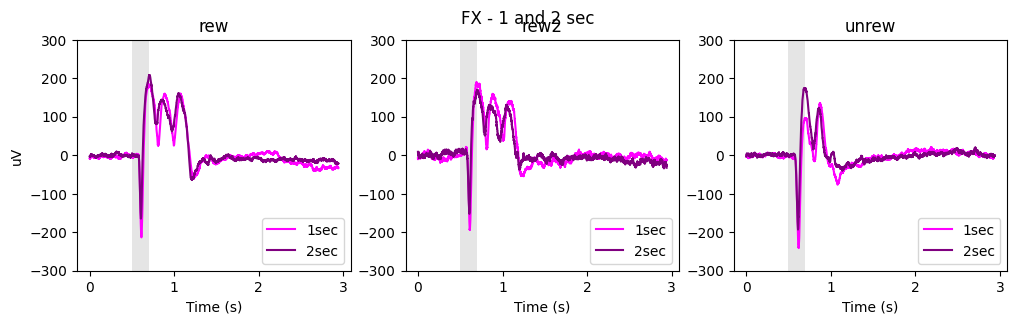

In [38]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 12.0 # x dimension
fig_size[1] = 3.0 # y dimension

plt.suptitle('FX - 1 and 2 sec')

ax1 = plt.subplot(131)
plt.plot(time_array, fx_rew_1sec, label='1sec', color='magenta')
plt.plot(time_array, fx_rew_2sec, label='2sec', color='purple')
plt.legend(loc="lower right")
plt.title('rew')
plt.xlabel('Time (s)')
plt.ylabel('uV')
plt.ylim([-300,300])
plt.axvspan(0.5, 0.7, alpha=0.2, facecolor='grey')

ax1 = plt.subplot(132, sharex=ax1, sharey=ax1)
plt.plot(time_array, fx_rew2_1sec, label='1sec', color='magenta')
plt.plot(time_array, fx_rew2_2sec, label='2sec', color='purple')
plt.legend(loc="lower right")
plt.title('rew2')
plt.xlabel('Time (s)')
plt.axvspan(0.5, 0.7, alpha=0.2, facecolor='grey')

ax1 = plt.subplot(133, sharex=ax1, sharey=ax1)
plt.plot(time_array, fx_unrew_1sec, label='1sec', color='magenta')
plt.plot(time_array, fx_unrew_2sec, label='2sec', color='purple')
plt.legend(loc="lower right")
plt.title('unrew')
plt.xlabel('Time (s)')
plt.axvspan(0.5, 0.7, alpha=0.2, facecolor='grey')


# Change the end of this next line with a new file name!!
# plt.savefig(r"U:\Data\zimmer94\Operant_Reward\lfp\VEPs\both_intervals\fx_3plots.pdf", transparent=True)

plt.show()